<a href="https://colab.research.google.com/github/nurgissas/ML-personal-learning/blob/main/day01_titanic_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 — Titanic EDA (starter notebook)
**Goal:** load the Titanic data, explore it, and write down findings with numbers.

**Your finished notebook must contain:**
1. ✅ Data loaded and inspected (`head`, `info`, missing-value counts)
2. ✅ Missing values handled (age filled with median)
3. ✅ Survival rate overall, by sex, and by class — actual numbers
4. ✅ 3 plots (survival by sex, by class, age histogram)
5. ✅ 3 findings written in your own words (markdown cells like this one)

Work top to bottom. Cells marked **TODO** are yours. Run a cell with **Shift+Enter**.

## Load the data — run ONLY ONE of the two cells below (A or B)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ── OPTION A: from your Google Drive ──────────────────────────────
# Your file lives at: MyDrive/ML-30/01/train.csv
from google.colab import drive
drive.mount('/content/drive')            # mount point is /content/drive — MyDrive appears under it

df = pd.read_csv('/content/drive/MyDrive/ML-30/01/train.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# ── OPTION B: straight from Kaggle via kagglehub ──────────────────
# Requirements: you clicked "Join Competition" on kaggle.com/c/titanic,
# and you're authenticated (Colab will prompt; or run kagglehub.login() first).
import kagglehub, os

path = kagglehub.competition_download('titanic')
print("Downloaded to:", path, "→ files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, 'train.csv'))
df.head()

# ── OPTION C (fallback, no accounts at all): ─────────────────────
# import seaborn as sns
# df = sns.load_dataset('titanic')   # note: lowercase column names (survived, sex, age...)

## 1. First look — what are we working with?

In [4]:
# Run these and READ the output. How many rows? Which columns have missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**TODO — your words (double-click me to edit):** How many passengers? Which columns are missing data, and how badly?

## 2. Handle missing values

In [6]:
# Age is the important missing column. Fill it with the median age.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isna().sum()   # should print 0

np.int64(0)

## 3. The key question: who survived?

In [8]:
# Overall survival rate
print('Overall:', df['Survived'].mean().round(3))

# EXAMPLE (done for you) — survival rate by sex.
# Copy this groupby pattern for the TODO cells below.
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Sex').Survived.mean())

Overall: 0.384
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [9]:
# TODO: survival rate by passenger class (Pclass) — same pattern as above
print(df.groupby('Pclass').Survived.mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [16]:
# TODO (bonus): survival by sex AND class together
# hint: df.groupby(['Sex','Pclass'])['Survived'].mean()
print(df.groupby(['Sex', 'Pclass']).Survived.mean().round(3))

Sex     Pclass
female  1         0.968
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: Survived, dtype: float64


## 4. Three plots

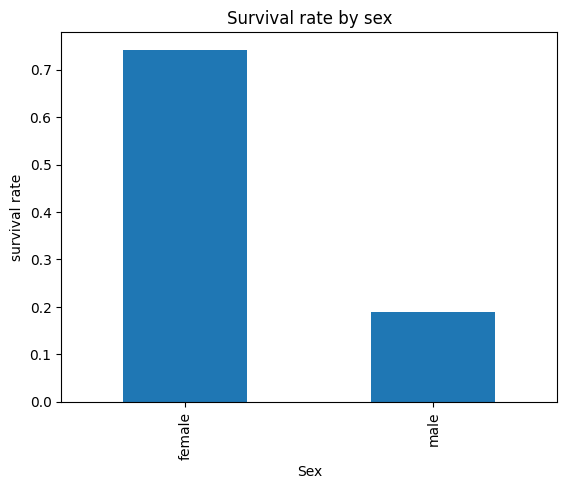

In [19]:
df.groupby('Sex')['Survived'].mean().plot.bar(title='Survival rate by sex')
plt.ylabel('survival rate')
plt.show()

Text(0, 0.5, 'survival rate')

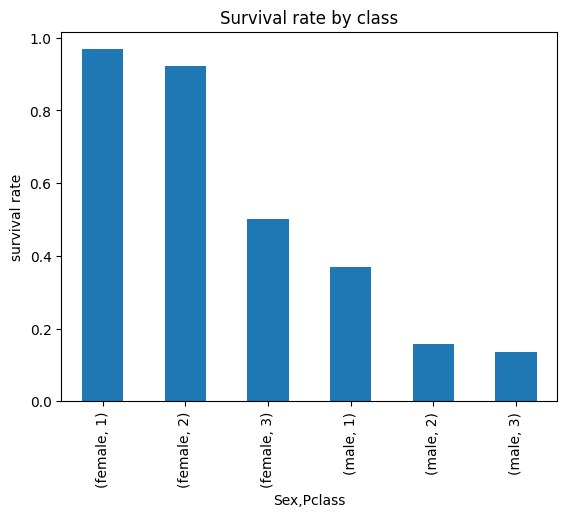

In [24]:
# TODO: same bar plot but for Pclass
df.groupby(['Sex','Pclass']).Survived.mean().plot.bar(title='Survival rate by class')
plt.ylabel('survival rate')

In [ ]:
# TODO: histogram of Age — try df['Age'].hist(bins=30)


## 5. Findings — the actual deliverable
**TODO:** write 3 findings below, each with a number. Example format:

- Women survived at ~74% vs ~19% for men — sex is the strongest predictor.
- female classes 1 and 2 survived more than any other groups (at 0.968 for 1, 0.921 for 2)
- Class 1 for both women and men had highest survival rate: 0.6296

## 6. Ship it
- Colab: **File → Save a copy in GitHub** → pick your `ml-30-days` repo → commit.
- A copy also auto-saves to your Drive (Colab Notebooks folder) — consider moving it to `MyDrive/ML-30/01/`.

Then open the app's Day 1 card, check the 🎯 criteria out loud, and tick the homework box. Done. 🎉